In [14]:
import pandas as pd
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [ ]:
def load_data(filepath, ticker, start_date=None, end_date=None):
    price = pd.read_parquet(filepath)
    df = price[['Open', 'High', 'Low', 'Close']].dropna()
    
    # Date Validation
    data_start = df.index.min()
    if start_date and pd.Timestamp(start_date) < data_start:
        print(f"[SKIP] {ticker}: data starts {data_start.date()}, requested {start_date}")
        return None, None  # return None to run_backtest
    
    if start_date:
        df = df[df.index >= pd.Timestamp(start_date)]
    if end_date:
        df = df[df.index <= pd.Timestamp(end_date)]

    monthly = df['Close'].groupby(pd.Grouper(freq="MS")).nth(0)
    return df, monthly

In [16]:
def calc_portfolio(df, monthly, investment):
    shares = investment / monthly
    cum_shares = shares.cumsum()
    daily_cum_shares = cum_shares.reindex(df.index, method="ffill")
    df['port_value'] = daily_cum_shares * df['Close']
    return df

In [ ]:
def calc_metrics(df, monthly, investment):
    
    # Basic Metrics
    total_invested = [-investment] * len(monthly)
    final_value = total_invested.copy()
    final_value[-1] += df['port_value'].iloc[-1]
    #IRR
    monthly_irr = npf.irr(final_value)
    annualized_irr = (1 + monthly_irr) ** 12 - 1

    #CAGR 計算 (for lum sum usually, comment out for DCA)
    #CAGR formula = (final value / initial value) ^ (1 / number of years)

    #years = (df.index[-1] - df.index[0]).days / 365 #find the total years
    #cagr = (df['port_value'].iloc[-1] / investment) ** (1 / years) - 1 


    #Cash flow series
    cashflow_series = pd.Series(0.0, index=df.index)
    cashflow_series.loc[monthly.index] = investment
    df['strategy_return'] = (
        df['port_value'] - df['port_value'].shift(1) - cashflow_series
    ) / df['port_value'].shift(1)

    #Sharpe Ratio and Sortino Ratio
    ret = df['strategy_return'].dropna()
    mean_return = ret.mean()
    std_return = ret.std()

    volatility = std_return * (252 ** 0.5)
    sharpe = mean_return / std_return * (252 ** 0.5)
    downside = ret[ret < 0]
    sortino = mean_return / downside.std() * (252 ** 0.5)

    #MDD
    cum_max = df['port_value'].cummax()
    mdd = (df['port_value'] / cum_max - 1).min()

#return all metrics as a dictionary
    return {
        "Total Invested": sum(total_invested),
        "Final Value":    final_value[-1],
        "IRR":            annualized_irr,
        #"CAGR":           cagr,
        "Volatility":     volatility,
        "Sharpe":         sharpe,
        "Sortino":        sortino,
        "MDD":            mdd,
    }

In [ ]:
def run_backtest(ticker, start_date=None, end_date=None, investment=1000):
    filepath = f"data/{ticker}.parquet"
    df, monthly = load_data(filepath, ticker, start_date, end_date)
    if df is None:
        return None, None
    df = calc_portfolio(df, monthly, investment)
    metrics = calc_metrics(df, monthly, investment)
    return metrics, df                            # 永遠只返回 dict

In [52]:
tickers = ["SPY", "QQQ", "IWY"]
start = "2010-01-01"
end = "2025-01-01"

metrics_dict = {}
df_dict  = {}

for ticker in tickers:
    #m is a dictionary of metrics, rs is a Series of rolling Sharpe ratios
    m, df = run_backtest(ticker, start, end)  # 拆 tuple
    if m is None:
        continue
    metrics_dict[ticker] = m
    df_dict [ticker] = df

pd.DataFrame(metrics_dict)

,SPY,QQQ,IWY
Total Invested,"-180,000.00","-180,000.00","-180,000.00"
Final Value,"570,648.49","877,721.76","817,869.46"
IRR,0.14,0.19,0.18
Volatility,0.17,0.20,0.19
Sharpe,0.84,0.93,0.93
Sortino,1.03,1.19,1.17
MDD,-0.33,-0.34,-0.31


In [ ]:
tickers = ["SPY", "QQQ", "IWY"]
start = "2010-01-01"
end = "2025-01-01"
dfs = {ticker: run_analysis(ticker, start, end) for ticker in tickers}
dfs = {t: df for t, df in dfs.items() if df is not None}

# Rolling Sharpe
rolling_sharpe = pd.DataFrame({
    ticker: (
        dfs[ticker]['strategy_return']
        .rolling(252)def calc_rolling(df_dict, window=252):
    result = {}
    for ticker, df in df_dict.items():
        ret = df['strategy_return'].dropna()
        result[ticker] = {
            "sharpe": retdef calc_rolling(df_dict, window=252):
    result = {}
    for ticker, df in df_dict.items():
        ret = df['strategy_return'].dropna()
        result[ticker] = {
            "sharpe": ret.rolling(window).apply(lambda x: x.mean() / x.std() * (252 ** 0.5)),
            "volatility": ret.rolling(window).std() * (252 ** 0.5),
            # 將來加 MDD、Sortino 都在這裡加一行
        }
    return result.rolling(window).apply(lambda x: x.mean() / x.std() * (252 ** 0.5)),
            "volatility": ret.rolling(window).std() * (252 ** 0.5),
            # 將來加 MDD、Sortino 都在這裡加一行
        }
    return result
        .apply(lambda x: x.mean() / x.std() * (252 ** 0.5))
    )
    for ticker in dfs
}).dropna()

# 將來加 Rolling Volatility，同一個 dfs 再用一次
rolling_vol = pd.DataFrame({
    ticker: dfs[ticker]['strategy_return'].rolling(252).std() * (252 ** 0.5)
    for ticker in dfs
}).dropna()

KeyError: 'strategy_return'

In [40]:
def run_backtest(ticker, start_date=None, end_date=None, investment=1000):
    filepath = f"data/{ticker}.parquet"
    df, monthly = load_data(filepath, ticker, start_date, end_date)
    if df is None:
        return None, None
    df = calc_portfolio(df, monthly, investment)
    metrics = calc_metrics(df, monthly, investment)
    
    ret = df['strategy_return'].dropna()
    rolling_sharpe = (
        ret.rolling(252)
        .apply(lambda x: x.mean() / x.std() * (252 ** 0.5))
    )
    return metrics, rolling_sharpe

In [ ]:
tickers = ["SPY", "QQQ", "IWY"]
start = "2010-01-01"
end = "2025-01-01"

metrics_dict = {}
rolling_dict = {}

for ticker in tickers:
    #m is a dictionary of metrics, rs is a Series of rolling Sharpe ratios
    m, rs = run_backtest(ticker, start, end)  # 拆 tuple
    if m is None:
        continue
    metrics_dict[ticker] = m
    rolling_dict[ticker] = rs

pd.DataFrame(metrics_dict)

,SPY,QQQ,IWY
Total Invested,"-180,000.00","-180,000.00","-180,000.00"
Final Value,"570,648.49","877,721.76","817,869.46"
IRR,0.14,0.19,0.18
Volatility,0.17,0.20,0.19
Sharpe,0.84,0.93,0.93
Sortino,1.03,1.19,1.17
MDD,-0.33,-0.34,-0.31


In [ ]:
# 多資產 rolling Sharpe DataFrame
rolling_df = pd.DataFrame(rolling_dict).dropna()

# describe
print(rolling_df.describe())

# 每個資產嘅最大最小日期
for ticker in rolling_df.columns:
    s = rolling_df[ticker]
    print(f"{ticker} | max: {s.idxmax().date()} ({s.max():.2f}) | min: {s.idxmin().date()} ({s.min():.2f})")

           SPY      QQQ      IWY
count 3,522.00 3,522.00 3,522.00
mean      1.10     1.14     1.18
std       0.86     0.83     0.87
min      -0.79    -1.17    -1.12
25%       0.41     0.54     0.56
50%       1.09     1.22     1.17
75%       1.79     1.74     1.76
max       3.60     3.15     4.14
SPY | max: 2018-01-23 (3.60) | min: 2022-12-28 (-0.79)
QQQ | max: 2018-01-23 (3.15) | min: 2022-12-28 (-1.17)
IWY | max: 2018-01-23 (4.14) | min: 2022-12-28 (-1.12)


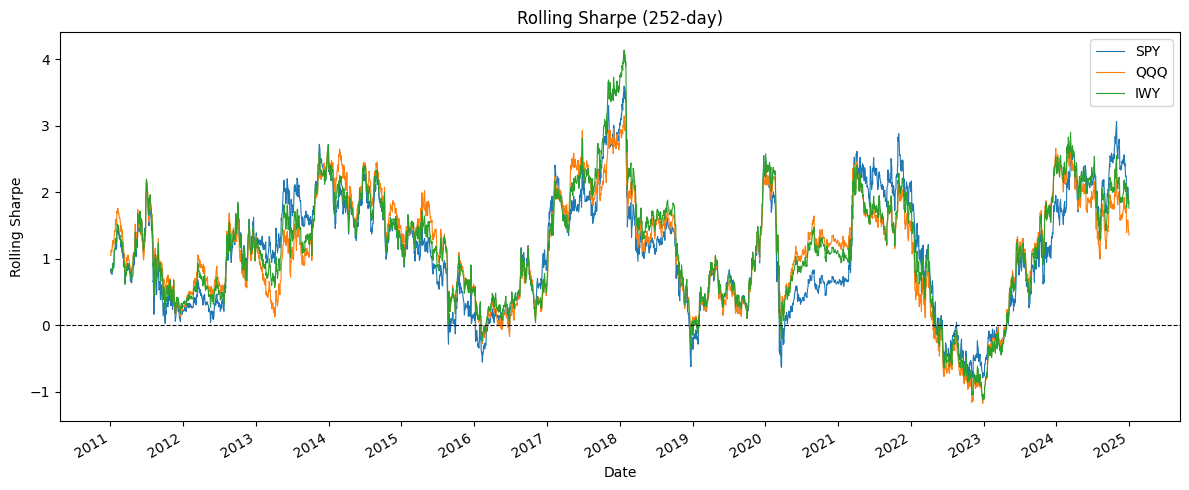

In [36]:
import matplotlib.dates as mdates

ax = rolling_df.plot(
    figsize=(12, 5),
    title="Rolling Sharpe (252-day)",
    linewidth=0.8
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
#ax.set_xlim(rolling_df.index[0], rolling_df.index[-1])
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Rolling Sharpe")

plt.tight_layout()
plt.show()

In [ ]:
# Summary (2008-2025, $1000/month DCA)
# IWY: Best risk-adjusted return (highest Sharpe mean, highest max)
# QQQ: Highest absolute return (IRR 19%) but worst downside (min -1.17)
# All three peaked 2018-01, bottomed 2022-12 → rate hike cycle visible in rolling Sharpe
# SPY: Most stable (lowest std 0.86), suitable as baseline

'\nDCA v1- columns.ipynb"tickers = ["SPY", "QQQ", "IWY"]\nstart = "2010-01-01"\nend = "2025-01-01"\nresults = {ticker: run_backtest(ticker, start, end) for ticker in tickers}\nresults = {ticker: metrics for ticker, metrics in results.items()if metrics is not None}\npd.DataFrame(results)\n'